
# Модель предсказания поведенческого скорринга. 

## Подготовка рабочего пространства


Банку нужно заранее оценивать риск того, что клиент уйдёт в дефолт (допустит просрочку ≥ 90 дней) в течение ближайшего года после даты скоринга.

Цель — построить модель, которая по историческим данным о клиенте, его транзакциях, кредитной истории и макроэкономике будет выдавать вероятность дефолта и помогать принимать решение: одобрять кредит или отказать.
В распоряжении есть несколько связанных таблиц:

- loan_payment_credit — эпизоды просрочек по кредиту (ID клиента, дата начала периода, количество дней просрочки).

- transactions — помесячные агрегированные траты по MCC‑категориям (ID, дата, суммы по разным типам расходов).

- client_description — демография клиента (возраст, семейное положение, наличие иждивенцев, дата регистрации).

- credit_description — кредитные параметры (доход клиента, сумма кредита).

- mortgage_presence — информация о наличии ипотеки и дате её открытия.

- credit_rating — помесячный кредитный рейтинг клиента.

- macro_data — макроэкономические показатели (учётная ставка, безработица, инфляция) по датам.

- cohort_grid — сетка когорт: ID клиента и score_date, даты, на которые нужно сформировать скоринг и целевую переменную.

Из этих таблиц собирается единый датасет master_df, где каждая строка — клиент в конкретную дату скоринга, с целевой меткой (дефолт в горизонте 12 месяцев) и набором статических и поведенческих признаков.

## Перевод бизнес-задачи на язык машинного обучения

Тип задачи
- Задача бинарной классификации: предсказать вероятность события target=1 (дефолт в течение 365 дней после score_date) по признакам клиента на момент скоринга.

Модели
- Планируется использовать:

Логистическую регрессию (baseline‑модель, хорошо интерпретируемая).

RandomForestClassifier как более гибкую нелинейную модель.

Для лучшей модели (RandomForest) — настройка гиперпараметров с помощью Optuna.

Все модели будут обучаться в пайплайне со встроенным препроцессингом (ColumnTransformer + OneHotEncoder для категориальных признаков).

* Методы работы с данными
Формирование целевой переменной по таблице loan_payment_credit с учётом временного окна [score_date, score_date + 365 дней) и исключением клиентов, у которых дефолт был до даты скоринга.

Объединение всех таблиц по ID и датам, строго используя только информацию на даты до score_date (избежание утечки будущего).

Создание новых поведенческих признаков:

- агрегаты по транзакциям (общие траты, вариативность, доли по MCC);

- финансовые соотношения (отношение суммы кредита к доходу и др.);

- преобразования кредитного рейтинга и демографии.

Разделение данных на train / calibration / test:

- обучение моделей на train,

- калибровка вероятностей на отдельной калибровочной выборке (1200 наблюдений),

- финальная оценка на независимом тесте (1200 наблюдений).

Балансировка классов (минимум через class_weight='balanced' в логистической регрессии и RandomForest) из‑за редкости дефолтов.

Как решать задачу
Построить единый датасет, провести EDA, создать новые признаки.

Обучить 4 базовые модели:

- логистическая регрессия и случайный лес без балансировки;

- логистическая регрессия и случайный лес с балансировкой классов.

С помощью Optuna подобрать гиперпараметры RandomForest, оптимизируя метрику missed defaults rate на калибровочной выборке.

Откалибровать лучшую версию RandomForest с помощью CalibratedClassifierCV и оценить калибровку по Brier score и калибровочной кривой.

Подобрать порог решения по калибровочной выборке, чтобы выполнить бизнес‑ограничения:

- approval rate ≥ 65%;

- default rate ≤ 2%;

- missed defaults rate ≤ 4%.

Проверить стабильность модели на тесте (матрица ошибок, ROC-AUC, precision, recall, F1, бизнес‑метрики).

Зафиксировать итоговую модель, найденный порог классификации и интерпретировать важность признаков через feature_importances_ RandomForest.


## Загрузка необходимых библиотек



In [1]:
!pip install -q optuna

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
# matplotlib.use("TkAgg") 
sns.set(style="whitegrid")

from sklearn.model_selection import GroupKFold
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve


import optuna


## Загрузка данных


In [2]:
RANDOM_SEED = 627
np.random.seed(RANDOM_SEED)

# Локальные пути
LOCAL_LOAN = 'ds_15_loan_payment_credit.csv'
LOCAL_TRANS = 'ds_15_transactions.csv'
LOCAL_CLIENT = 'ds_15_client_description.csv'
LOCAL_CREDIT = 'ds_15_credit_description.csv'
LOCAL_MORTGAGE = 'ds_15_mortgage_presence.csv'
LOCAL_RATING = 'ds_15_credit_rating.csv'
LOCAL_MACRO = 'ds_15_macro_data.csv'
LOCAL_COHORT = 'ds_15_cohort_grid.csv'

# Серверные пути
SERVER_LOAN = '/datasets/ds_15_loan_payment_credit.csv'
SERVER_TRANS = '/datasets/ds_15_transactions.csv'
SERVER_CLIENT = '/datasets/ds_15_client_description.csv'
SERVER_CREDIT = '/datasets/ds_15_credit_description.csv'
SERVER_MORTGAGE = '/datasets/ds_15_mortgage_presence.csv'
SERVER_RATING = '/datasets/ds_15_credit_rating.csv'
SERVER_MACRO = '/datasets/ds_15_macro_data.csv'
SERVER_COHORT = '/datasets/ds_15_cohort_grid.csv'


def get_path(local, server):
    if os.path.exists(local):
        return local
    elif os.path.exists(server):
        return server
    else:
        raise FileNotFoundError(f'Файл не найден: {local} или {server}')


LOAN_PATH = get_path(LOCAL_LOAN, SERVER_LOAN)
TRANS_PATH = get_path(LOCAL_TRANS, SERVER_TRANS)
CLIENT_PATH = get_path(LOCAL_CLIENT, SERVER_CLIENT)
CREDIT_PATH = get_path(LOCAL_CREDIT, SERVER_CREDIT)
MORTGAGE_PATH = get_path(LOCAL_MORTGAGE, SERVER_MORTGAGE)
RATING_PATH = get_path(LOCAL_RATING, SERVER_RATING)
MACRO_PATH = get_path(LOCAL_MACRO, SERVER_MACRO)
COHORT_PATH = get_path(LOCAL_COHORT, SERVER_COHORT)

print("Файлы найдены:")
print(LOAN_PATH)
print(TRANS_PATH)
print(CLIENT_PATH)
print(CREDIT_PATH)
print(MORTGAGE_PATH)
print(RATING_PATH)
print(MACRO_PATH)
print(COHORT_PATH)

Файлы найдены:
/datasets/ds_15_loan_payment_credit.csv
/datasets/ds_15_transactions.csv
/datasets/ds_15_client_description.csv
/datasets/ds_15_credit_description.csv
/datasets/ds_15_mortgage_presence.csv
/datasets/ds_15_credit_rating.csv
/datasets/ds_15_macro_data.csv
/datasets/ds_15_cohort_grid.csv


In [3]:
loan = pd.read_csv(LOAN_PATH, parse_dates=['дата_начала_периода'])
trans = pd.read_csv(TRANS_PATH, parse_dates=['date'])
clients = pd.read_csv(CLIENT_PATH, parse_dates=['дата_регистрации'])
credit = pd.read_csv(CREDIT_PATH)
mortgage = pd.read_csv(MORTGAGE_PATH, parse_dates=['дата_открытия'])
rating = pd.read_csv(RATING_PATH, parse_dates=['date'])
macro = pd.read_csv(MACRO_PATH, parse_dates=['date'])
cohort = pd.read_csv(COHORT_PATH, parse_dates=['score_date'])


In [4]:
datasets = {
    'loan': loan,
    'transactions': trans,
    'clients': clients,
    'credit': credit,
    'mortgage': mortgage,
    'rating': rating,
    'macro': macro,
    'cohort': cohort
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    display(df.shape)
    display(df.head())
    display(df.dtypes)



LOAN


(5500, 3)

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


ID                             object
дата_начала_периода    datetime64[ns]
просрочка_дней                  int64
dtype: object


TRANSACTIONS


...

date                   datetime64[ns]
учетная_ставка                float64
уровень_безработицы           float64
инфляция                      float64
dtype: object


COHORT


(577494, 2)

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


ID                    object
score_date    datetime64[ns]
dtype: object

## Исследовательский анализ данных




ТАБЛИЦА: loan

 Размер и структура
Строк: 5,500
Признаков: 3


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


ID                             object
дата_начала_периода    datetime64[ns]
просрочка_дней                  int64
dtype: object


 Типы признаков
Числовые: ['просрочка_дней']
Категориальные: ['ID']
Даты: ['дата_начала_периода']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
дата_начала_периода,0,0.0
просрочка_дней,0,0.0


...

,count,mean,std,min,1%,5%,50%,95%,99%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,80.0,83.0,115.0,147.0,150.0,150.0



 Категориальная статистика (describe)


,count,unique,top,freq
ID,5500,5500,IDF55127900,1



 Анализ дат

Колонка даты: дата_начала_периода
Минимальная дата: 2013-11-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 73


дата_начала_периода
2013-11-30     4
2013-12-31    14
2014-01-31    15
2014-02-28    27
2014-03-31    30
Freq: M, Name: count, dtype: int64

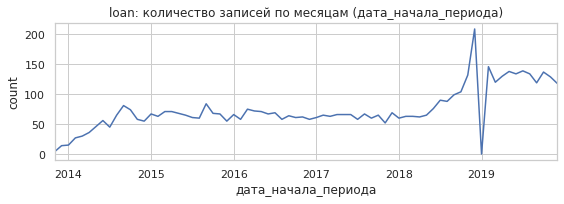


 Распределения числовых признаков (гистограммы + боксплоты)


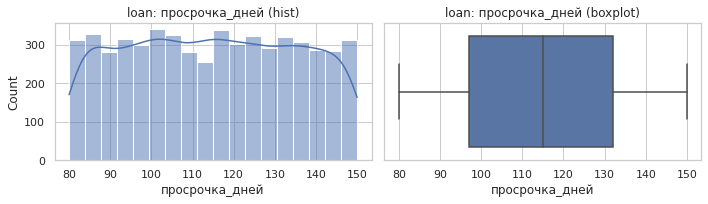


 Категориальные признаки (топ-частоты)

Признак: ID


IDF55127900    1
IDF55023860    1
IDF55083854    1
IDF54906025    1
IDF55146010    1
IDF55049848    1
IDF54905250    1
IDF55077565    1
IDF55129980    1
IDF55071816    1
Name: ID, dtype: int64

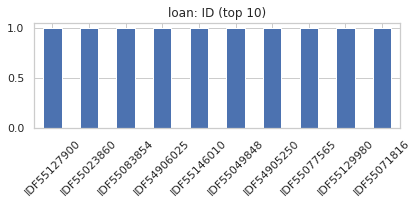


 EDA для loan завершён

ТАБЛИЦА: transactions

 Размер и структура
Строк: 577,494
Признаков: 10


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


ID                    object
date          datetime64[ns]
MCC_5300             float64
MCC_5814             float64
MCC_5812             float64
MCC_5411             float64
MCC_3990             float64
MCC_5722             float64
MCC_4900             float64
MCC_другое           float64
dtype: object


 Типы признаков
Числовые: ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
Категориальные: ['ID']
Даты: ['date']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
date,0,0.0
MCC_5300,0,0.0
MCC_5814,0,0.0
MCC_5812,0,0.0
MCC_5411,0,0.0
MCC_3990,0,0.0
MCC_5722,0,0.0
MCC_4900,0,0.0
MCC_другое,0,0.0


...

,count,mean,std,min,1%,5%,50%,95%,99%,max
MCC_5300,577494.0,6177.123479,8835.871514,162.91,302.8600,491.7165,2659.590,24315.1275,43292.8524,86939.40
MCC_5814,577494.0,3507.682295,5710.755226,62.18,113.7800,195.0465,1233.110,15854.8770,28208.8184,55720.69
MCC_5812,577494.0,2993.862550,4541.119582,67.06,128.3900,214.3500,1224.530,12120.5865,23089.2417,47969.57
MCC_5411,577494.0,9263.099506,12299.732992,286.11,513.7593,800.9830,4115.385,37131.6915,54965.1750,101301.95
MCC_3990,577494.0,1128.116742,1557.157475,31.90,56.8893,90.5900,476.890,4597.9505,6940.9619,14261.49
MCC_5722,577494.0,3604.437043,5005.896972,108.40,190.6993,302.4800,1590.120,13751.7250,23346.3659,54630.19
MCC_4900,577494.0,3682.487182,5567.979383,81.29,151.4900,249.0765,1397.065,15654.9200,26814.2777,52987.53
MCC_другое,577494.0,5414.896895,7190.882383,166.26,300.4186,467.6365,2398.330,21733.4030,32013.4890,60033.55



 Категориальная статистика (describe)


,count,unique,top,freq
ID,577494,13500,IDF54982764,84



 Анализ дат

Колонка даты: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


date
2013-01-31    152
2013-02-28    284
2013-03-31    457
2013-04-30    636
2013-05-31    797
Freq: M, Name: count, dtype: int64

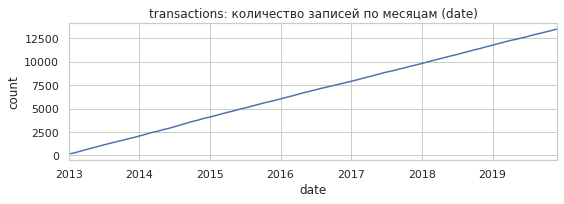


 Распределения числовых признаков (гистограммы + боксплоты)


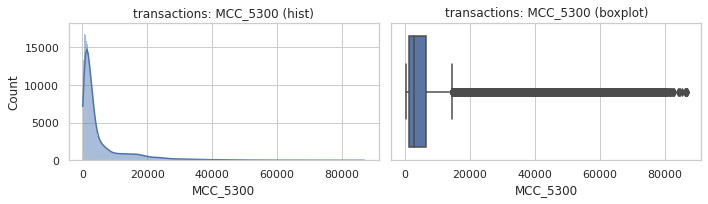

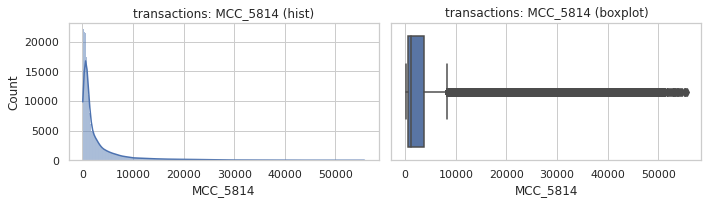

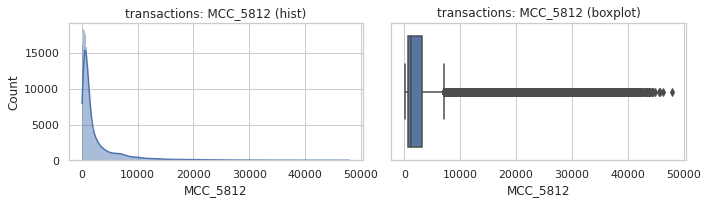

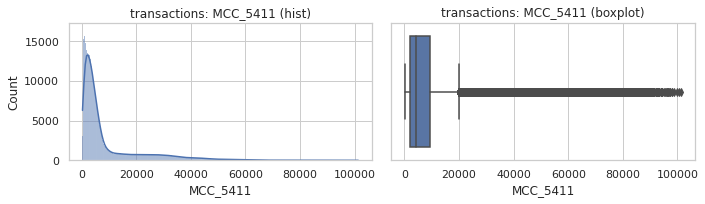

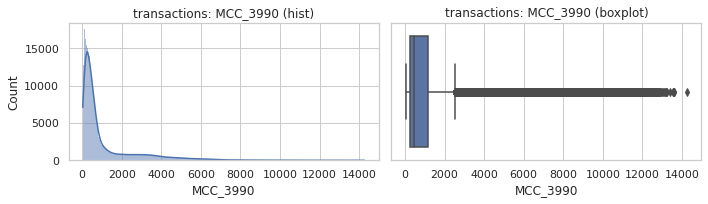

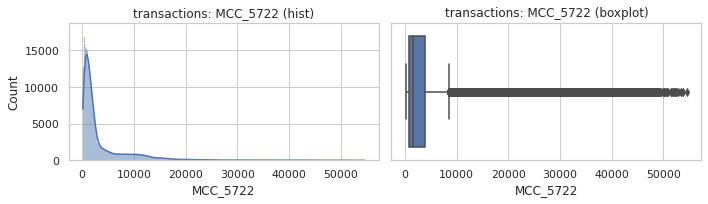

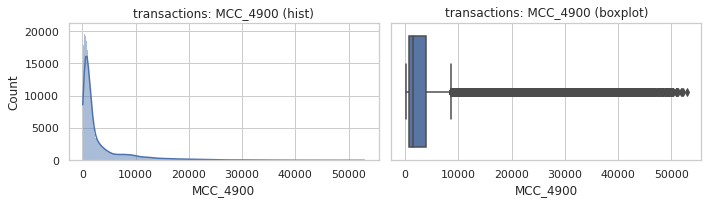

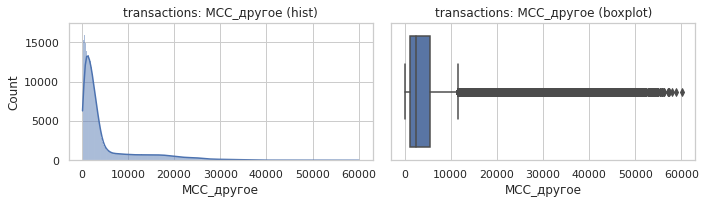


 Категориальные признаки (топ-частоты)

Признак: ID


IDF54982764    84
IDF55119652    84
IDF55126600    84
IDF55106956    84
IDF55076663    84
IDF55025827    84
IDF54912057    84
IDF55141424    84
IDF55132892    84
IDF55136147    84
Name: ID, dtype: int64

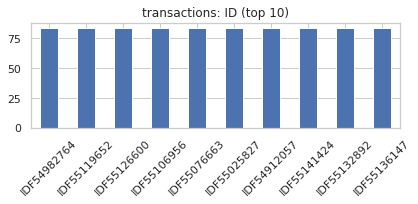


 Корреляции числовых признаков (heatmap, первые 10)


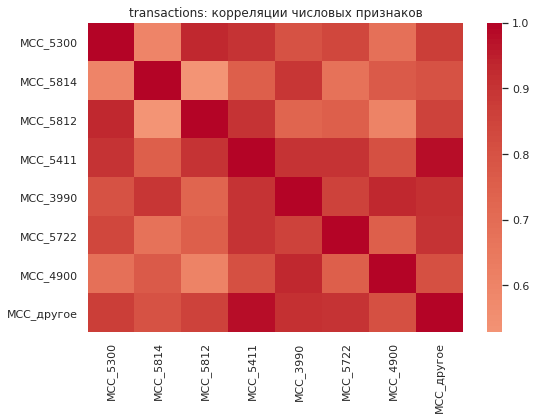


 EDA для transactions завершён

ТАБЛИЦА: clients

 Размер и структура
Строк: 13,500
Признаков: 5


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


ID                            object
возраст                        int64
семейное_положение            object
наличие_иждивенцев             int64
дата_регистрации      datetime64[ns]
dtype: object


 Типы признаков
Числовые: ['возраст', 'наличие_иждивенцев']
Категориальные: ['ID', 'семейное_положение']
Даты: ['дата_регистрации']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
возраст,0,0.0
семейное_положение,0,0.0
наличие_иждивенцев,0,0.0
дата_регистрации,0,0.0


...

,count,mean,std,min,1%,5%,50%,95%,99%,max
возраст,13500.0,41.304815,15.096673,18.0,18.0,19.0,40.0,66.0,69.0,69.0
наличие_иждивенцев,13500.0,0.484741,0.499786,0.0,0.0,0.0,0.0,1.0,1.0,1.0



 Категориальная статистика (describe)


,count,unique,top,freq
ID,13500,13500,IDF55014781,1
семейное_положение,13500,3,нет семьи,4584



 Анализ дат

Колонка даты: дата_регистрации
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


дата_регистрации
2013-01-31    152
2013-02-28    132
2013-03-31    173
2013-04-30    179
2013-05-31    161
Freq: M, Name: count, dtype: int64

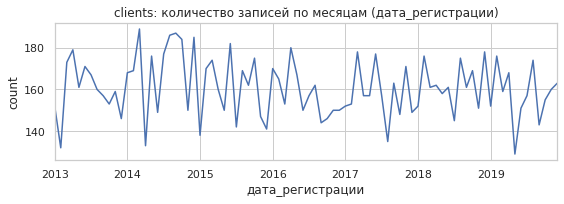


 Распределения числовых признаков (гистограммы + боксплоты)


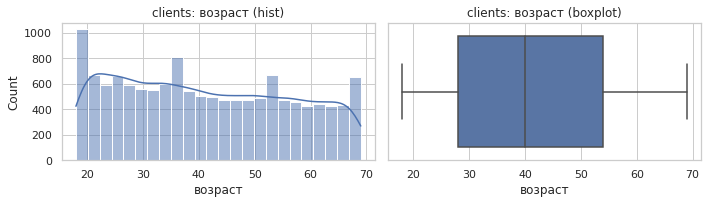

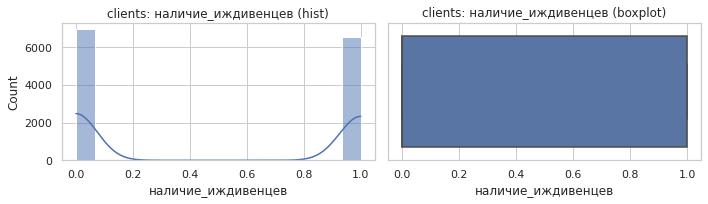


 Категориальные признаки (топ-частоты)

Признак: ID


IDF55014781    1
IDF55006703    1
IDF55064041    1
IDF55039588    1
IDF54958470    1
IDF55086728    1
IDF54927224    1
IDF55038493    1
IDF55142229    1
IDF54953902    1
Name: ID, dtype: int64

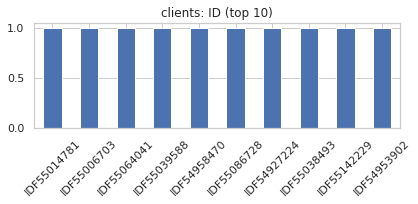


Признак: семейное_положение


нет семьи      4584
разведённые    4519
есть семья     4397
Name: семейное_положение, dtype: int64

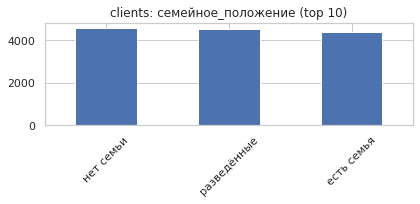


 Корреляции числовых признаков (heatmap, первые 10)


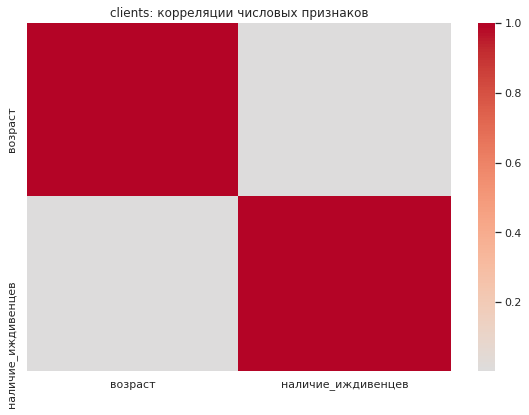


 EDA для clients завершён

ТАБЛИЦА: credit

 Размер и структура
Строк: 13,500
Признаков: 3


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


ID               object
доход             int64
сумма_кредита     int64
dtype: object


 Типы признаков
Числовые: ['доход', 'сумма_кредита']
Категориальные: ['ID']
Даты: []

 Пропуски


,missing_count,missing_percent
ID,0,0.0
доход,0,0.0
сумма_кредита,0,0.0



 Дубликаты
Полные дубликаты строк: 0
Уникальных ID: 13500

 Числовая статистика (describe)


,count,mean,std,min,1%,5%,50%,95%,99%,max
доход,13500.0,7.908927e+04,4.004555e+04,15010.0,15792.89,19272.45,77991.5,143065.05,148734.06,149988.0
сумма_кредита,13500.0,1.993383e+06,1.061381e+06,75000.0,114986.40,298056.00,2032732.5,3594854.25,3714270.75,3749400.0



 Категориальная статистика (describe)


,count,unique,top,freq
ID,13500,13500,IDF55014781,1



 Распределения числовых признаков (гистограммы + боксплоты)


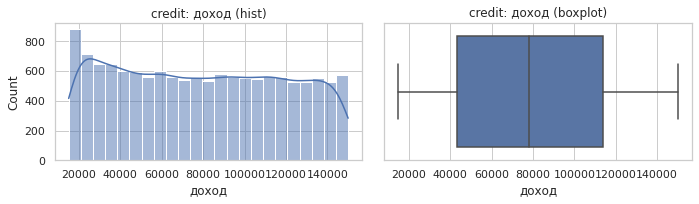

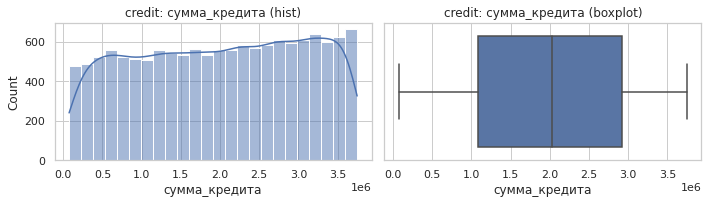


 Категориальные признаки (топ-частоты)

Признак: ID


IDF55014781    1
IDF55006703    1
IDF55064041    1
IDF55039588    1
IDF54958470    1
IDF55086728    1
IDF54927224    1
IDF55038493    1
IDF55142229    1
IDF54953902    1
Name: ID, dtype: int64

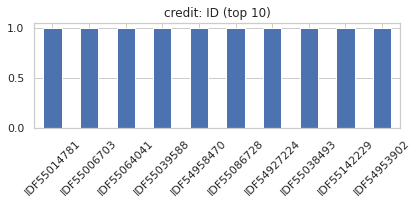


 Корреляции числовых признаков (heatmap, первые 10)


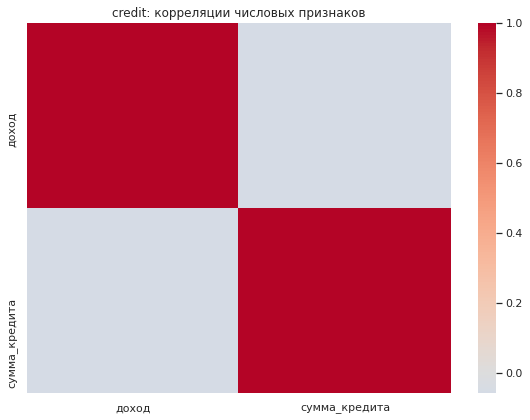


 EDA для credit завершён

ТАБЛИЦА: mortgage

 Размер и структура
Строк: 6,609
Признаков: 3


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


ID                         object
дата_открытия      datetime64[ns]
наличие_ипотеки             int64
dtype: object


 Типы признаков
Числовые: ['наличие_ипотеки']
Категориальные: ['ID']
Даты: ['дата_открытия']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
дата_открытия,0,0.0
наличие_ипотеки,0,0.0


...

,count,mean,std,min,1%,5%,50%,95%,99%,max
наличие_ипотеки,6609.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



 Категориальная статистика (describe)


,count,unique,top,freq
ID,6609,6609,IDF55014781,1



 Анализ дат

Колонка даты: дата_открытия
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


дата_открытия
2013-01-31    74
2013-02-28    66
2013-03-31    86
2013-04-30    76
2013-05-31    73
Freq: M, Name: count, dtype: int64

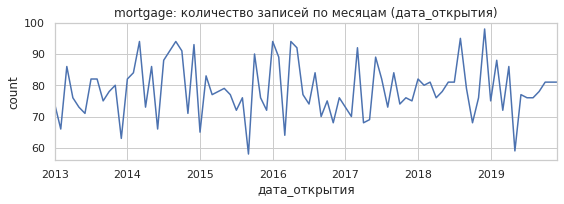


 Распределения числовых признаков (гистограммы + боксплоты)


/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


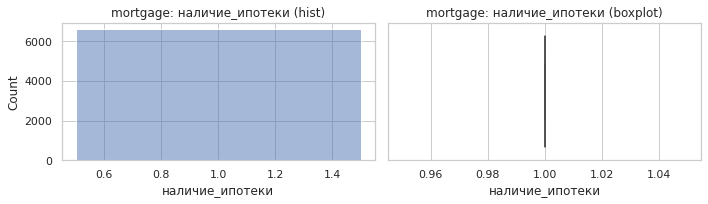


 Категориальные признаки (топ-частоты)

Признак: ID


IDF55014781    1
IDF55148822    1
IDF55014572    1
IDF55004758    1
IDF54949758    1
IDF54984924    1
IDF55086084    1
IDF55095055    1
IDF54977285    1
IDF55125399    1
Name: ID, dtype: int64

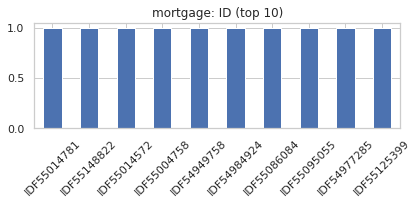


 EDA для mortgage завершён

ТАБЛИЦА: rating

 Размер и структура
Строк: 577,494
Признаков: 3


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


ID                           object
date                 datetime64[ns]
кредитный_рейтинг             int64
dtype: object


 Типы признаков
Числовые: ['кредитный_рейтинг']
Категориальные: ['ID']
Даты: ['date']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
date,0,0.0
кредитный_рейтинг,0,0.0


...

,count,mean,std,min,1%,5%,50%,95%,99%,max
кредитный_рейтинг,577494.0,603.190961,64.358896,343.0,463.0,502.0,600.0,714.0,759.0,900.0



 Категориальная статистика (describe)


,count,unique,top,freq
ID,577494,13500,IDF54982764,84



 Анализ дат

Колонка даты: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


date
2013-01-31    152
2013-02-28    284
2013-03-31    457
2013-04-30    636
2013-05-31    797
Freq: M, Name: count, dtype: int64

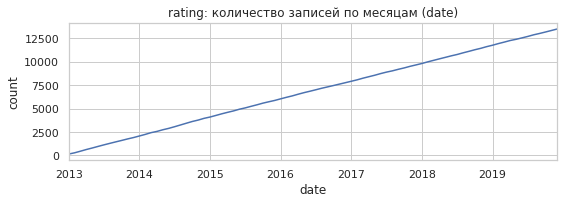


 Распределения числовых признаков (гистограммы + боксплоты)


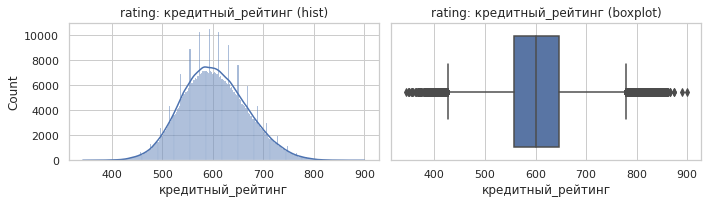


 Категориальные признаки (топ-частоты)

Признак: ID


IDF54982764    84
IDF55119652    84
IDF55126600    84
IDF55106956    84
IDF55076663    84
IDF55025827    84
IDF54912057    84
IDF55141424    84
IDF55132892    84
IDF55136147    84
Name: ID, dtype: int64

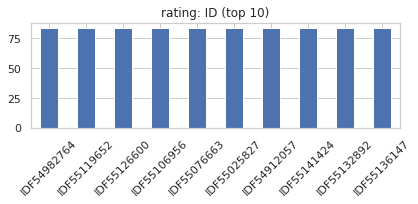


 EDA для rating завершён

ТАБЛИЦА: macro

 Размер и структура
Строк: 84
Признаков: 4


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


date                   datetime64[ns]
учетная_ставка                float64
уровень_безработицы           float64
инфляция                      float64
dtype: object


 Типы признаков
Числовые: ['учетная_ставка', 'уровень_безработицы', 'инфляция']
Категориальные: []
Даты: ['date']

 Пропуски


,missing_count,missing_percent
date,0,0.0
учетная_ставка,0,0.0
уровень_безработицы,0,0.0
инфляция,0,0.0



 Дубликаты
Полные дубликаты строк: 0

 Числовая статистика (describe)


,count,mean,std,min,1%,5%,50%,95%,99%,max
учетная_ставка,84.0,8.638517,2.466112,5.50,5.500,5.50,7.750,13.361842,15.3400,17.00
уровень_безработицы,84.0,5.175000,0.409488,4.30,4.383,4.50,5.200,5.800000,5.9170,6.00
инфляция,84.0,0.527500,0.570189,-0.54,-0.291,0.01,0.425,1.181500,2.8291,3.85



 Категориальная статистика (describe)

 Анализ дат

Колонка даты: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


date
2013-01-31    1
2013-02-28    1
2013-03-31    1
2013-04-30    1
2013-05-31    1
Freq: M, Name: count, dtype: int64

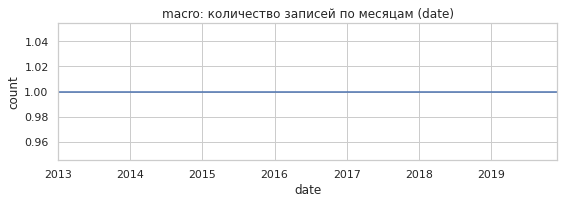


 Распределения числовых признаков (гистограммы + боксплоты)


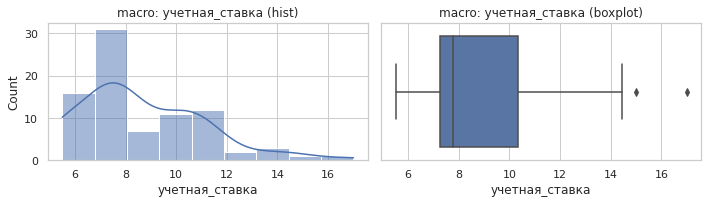

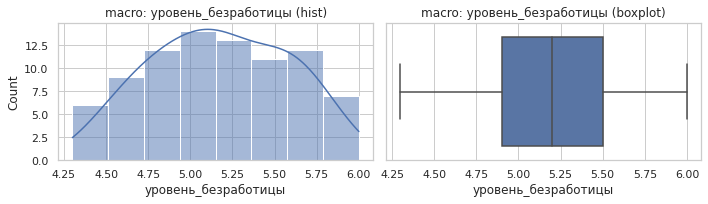

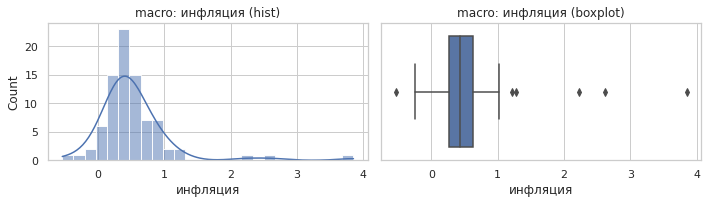


 Категориальные признаки (топ-частоты)

 Корреляции числовых признаков (heatmap, первые 10)


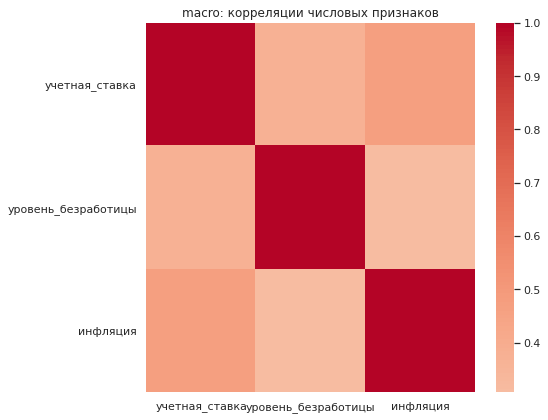


 EDA для macro завершён

ТАБЛИЦА: cohort

 Размер и структура
Строк: 577,494
Признаков: 2


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


ID                    object
score_date    datetime64[ns]
dtype: object


 Типы признаков
Числовые: []
Категориальные: ['ID']
Даты: ['score_date']

 Пропуски


,missing_count,missing_percent
ID,0,0.0
score_date,0,0.0



 Дубликаты
Полные дубликаты строк: 0
Уникальных ID: 13500

 Числовая статистика (describe)

 Категориальная статистика (describe)


,count,unique,top,freq
ID,577494,13500,IDF54982764,84



 Анализ дат

Колонка даты: score_date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Количество уникальных дат: 84


score_date
2013-01-31    152
2013-02-28    284
2013-03-31    457
2013-04-30    636
2013-05-31    797
Freq: M, Name: count, dtype: int64

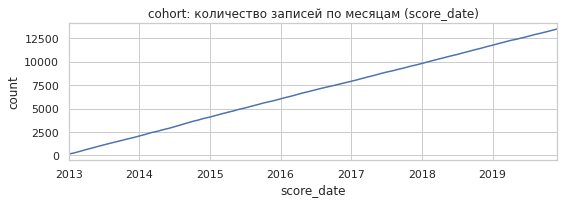


 Распределения числовых признаков (гистограммы + боксплоты)

 Категориальные признаки (топ-частоты)

Признак: ID


IDF54982764    84
IDF55119652    84
IDF55126600    84
IDF55106956    84
IDF55076663    84
IDF55025827    84
IDF54912057    84
IDF55141424    84
IDF55132892    84
IDF55136147    84
Name: ID, dtype: int64

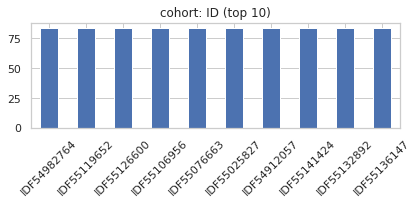


 EDA для cohort завершён


In [5]:
def eda_table(df, name, target=None, id_col='ID'):
    print(f"\n{'='*80}")
    print(f"ТАБЛИЦА: {name}")
    print(f"{'='*80}\n")

    # ---- Общая информация ----
    print(" Размер и структура")
    print(f"Строк: {df.shape[0]:,}")
    print(f"Признаков: {df.shape[1]:,}")
    display(df.head())
    display(df.dtypes)

    # отдельный блок по типам
    print("\n Типы признаков")
    num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()
    date_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

    print("Числовые:", num_cols)
    print("Категориальные:", cat_cols)
    print("Даты:", date_cols)

    # ---- Пропуски ----
    print("\n Пропуски")
    missing = df.isna().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = (
        pd.DataFrame({
            "missing_count": missing,
            "missing_percent": missing_percent
        })
        .sort_values("missing_percent", ascending=False)
        .round(2)
    )
    display(missing_df)

    # ---- Дубликаты ----
    print("\n Дубликаты")
    full_dups = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dups)
    if id_col in df.columns:
        print("Уникальных ID:", df[id_col].nunique())

    # ---- describe() по числам и категориям ----
    print("\n Числовая статистика (describe)")
    if len(num_cols) > 0:
        display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

    print("\n Категориальная статистика (describe)")
    if len(cat_cols) > 0:
        display(df[cat_cols].describe().T)

    # ---- Анализ дат ----
    if len(date_cols) > 0:
        print("\n Анализ дат")
        for col in date_cols:
            print(f"\nКолонка даты: {col}")
            print("Минимальная дата:", df[col].min())
            print("Максимальная дата:", df[col].max())
            print("Количество уникальных дат:", df[col].nunique())
            # простой временной профиль
            tmp = (
                df.set_index(col)
                  .resample('M')
                  .size()
                  .rename('count')
            )
            display(tmp.head())
            plt.figure(figsize=(8,3))
            tmp.plot()
            plt.title(f"{name}: количество записей по месяцам ({col})")
            plt.ylabel("count")
            plt.tight_layout()
            plt.show()

    # ---- Анализ таргета ----
    if target and target in df.columns:
        print("\n Анализ целевой переменной")
        print("Распределение классов:")
        display(df[target].value_counts())
        print("Доля классов:")
        display(df[target].value_counts(normalize=True).round(4))

    # ---- Распределения числовых признаков ----
    print("\n Распределения числовых признаков (гистограммы + боксплоты)")
    max_plots = 8  # чтобы не рисовать слишком много за раз
    for col in num_cols[:max_plots]:
        fig, axes = plt.subplots(1, 2, figsize=(10,3))

        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f"{name}: {col} (hist)")

        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"{name}: {col} (boxplot)")

        plt.tight_layout()
        plt.show()

    # ---- Категориальные признаки ----
    print("\n Категориальные признаки (топ-частоты)")
    for col in cat_cols[:5]:
        print(f"\nПризнак: {col}")
        vc = df[col].value_counts(dropna=False)
        display(vc.head(10))
        plt.figure(figsize=(6,3))
        vc.head(10).plot(kind="bar")
        plt.title(f"{name}: {col} (top 10)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ---- Корреляции ----
    if len(num_cols) > 1:
        print("\n Корреляции числовых признаков (heatmap, первые 10)")
        corr = df[num_cols].corr()
        cols_corr = corr.columns[:10]
        plt.figure(figsize=(8,6))
        sns.heatmap(corr.loc[cols_corr, cols_corr], annot=False, cmap='coolwarm', center=0)
        plt.title(f"{name}: корреляции числовых признаков")
        plt.tight_layout()
        plt.show()

    # ---- Числовые признаки vs таргет ----
    if target and target in df.columns and len(num_cols) > 0:
        print("\n Взаимосвязь числовых признаков с target (boxplot по классам)")
        for col in num_cols[:5]:
            plt.figure(figsize=(5,3))
            sns.boxplot(data=df, x=target, y=col)
            plt.title(f"{name}: {col} по классам {target}")
            plt.tight_layout()
            plt.show()

    print(f"\n EDA для {name} завершён")

eda_table(loan, 'loan')
eda_table(trans, 'transactions')
eda_table(clients, 'clients')
eda_table(credit, 'credit')
eda_table(mortgage, 'mortgage')
eda_table(rating, 'rating')
eda_table(macro, 'macro')
eda_table(cohort, 'cohort')


Таблица loan

Размер: 5,500 клиентов, 3 признака.

Целевая переменная: просрочка_дней (int, без пропусков).

Особенности:

Нет пропусков и дубликатов.

Распределение просрочка_дней сосредоточено вокруг 115 дней (mean ≈ 115, median ≈ 115), min=80, max=150 достаточно узкий диапазон.

Выводы:

Можно рассматривать как задачу регрессии (количество дней просрочки) или классификации (например, дефолт ≥ 90 дней).

Признак ID уникален, не несёт информации сам по себе.

Признак даты дата_начала_периода можно использовать для извлечения сезонности или экономических условий.

Таблица transactions

Размер: 577,494 строк (много транзакций на 13,500 клиентов), 10 признаков.

Особенности:

Признаки MCC — расходные категории (числовые), без пропусков.

Даты транзакций с 2013 по 2019, ежемесячные агрегации.

ID повторяется по количеству транзакций.

Выводы:

Нужно агрегировать транзакции на уровень клиента (среднее, сумма, std, max по категориям).

Можно извлечь поведенческие фичи: активность по категориям, траты в разные сезоны, рост/падение расходов.

MCC колонки можно стандартизовать или нормализовать для модели.

 Таблица clients

Размер: 13,500 клиентов, 5 признаков.

Особенности:

возраст, наличие_иждивенцев числовые.

семейное_положение категориальное (3 категории).

Дата регистрации есть, может дать “возраст клиента в системе”.

Выводы:

Признаки полезны для кредитного скоринга.

Можно создать новые фичи: возраст + семейное положение, срок с даты регистрации.

Все признаки без пропусков сразу в pipeline.

Таблица credit

Размер: 13,500 клиентов, 3 признака.

Особенности:

Доход и сумма кредита числовые.

Нет пропусков и дубликатов.

Выводы:

Признаки напрямую полезны для предсказания дефолта (просрочка_дней).

Можно создавать фичи: отношение кредита к доходу, логарифмы дохода/кредита.

Таблица mortgage

Размер: 6,609 клиентов, 3 признака.

Особенности:

Наличие ипотеки бинарное.

Выводы:

Признак почти не вариативен, может быть неинформативен для модели.

Можно просто оставить как бинарный индикатор.

Таблица rating

Размер: 577,494 строк (ежемесячный кредитный рейтинг клиентов).

Особенности:

Кредитный рейтинг int, диапазон 343–900.

Можно агрегировать по клиенту: средний рейтинг, тренд по времени.

Выводы:

Полезно для скоринга: текущий рейтинг, динамика.

Даты и ID позволяют соединять с транзакциями.

Таблица macro

Размер: 84 строки (месячные макроэкономические данные).

Особенности:

Признаки: учетная ставка, уровень безработицы, инфляция.

Нет пропусков.

Выводы:

Можно добавить клиенту фичи по дате: макроэкономические условия на момент начала периода кредита.

Это поможет учесть внешние факторы риска.

Таблица cohort

Размер: 577,494 строки, ID и score_date.

Особенности:

Совпадает по количеству с transactions и rating.

Дата оценки позволяет соединить все временные данные для конкретного месяца.

Общие выводы по EDA

Целевая переменная: просрочка_дней в loan дефолт ≥ 90 дней можно бинаризовать.

Многоуровневые данные: таблицы клиентов (clients, credit, mortgage) + транзакции и рейтинги нужно агрегировать транзакции/рейтинги по клиенту.

Временные признаки: даты кредитов, транзакций, регистраций создать фичи “возраст кредита”, “возраст клиента в системе”, макроэкономические условия на дату.

Категориальные признаки: ID не используется напрямую, только для объединения таблиц.

Микс типов: числовые, категориальные и бинарные признаки есть, пропусков нет pipeline прост: Imputer + OneHotEncoder (категории) + StandardScaler (число).

Предупреждения: таблица mortgage почти без вариации можно убрать или оставить как бинарный индикатор.

Сложность модели: данные хорошо подходят для ансамблей и для логистической регрессии с регуляризацией.

## Объединение таблиц



In [6]:
def build_scoring_dataset(data):

    cohort = data['cohort'].sort_values(['ID','score_date'])
    master_df = cohort.copy()

    # === TARGET ===
    loan = data['loan']
    loan90 = loan[loan['просрочка_дней'] >= 90]
    first_default = (
        loan90.sort_values('дата_начала_периода')
        .groupby('ID').first().reset_index()
    )

    master_df = master_df.merge(
        first_default[['ID','дата_начала_периода']], 
        on='ID', how='left'
    )

    master_df['past'] = master_df['дата_начала_периода'] < master_df['score_date']
    master_df['future'] = (
        (master_df['дата_начала_периода'] >= master_df['score_date']) &
        (master_df['дата_начала_периода'] < master_df['score_date'] + pd.Timedelta(days=365))
    )

    max_loan_date = loan['дата_начала_периода'].max()
    master_df = master_df[
        master_df['score_date'] <= max_loan_date - pd.Timedelta(days=365)
    ]

    master_df['target'] = np.where(
        master_df['past'], 
        np.nan, 
        master_df['future'].astype(int)
    )

    master_df = master_df.dropna(subset=['target']) \
                         .drop(columns=['past','future','дата_начала_периода'])

    # === TRANSACTIONS (Δ month) ===
    trans = data['transactions']
    mcc = [c for c in trans.columns if c.startswith('MCC')]

    trans = trans.sort_values(['ID','date'])
    trans[mcc] = trans.groupby('ID')[mcc].ffill()

    diff = trans.groupby('ID')[mcc].diff()
    diff['ID'] = trans['ID']
    diff['date'] = trans['date'] + pd.DateOffset(months=1)

    diff = diff.dropna()

    master_df = master_df.merge(
        diff, 
        left_on=['ID','score_date'], 
        right_on=['ID','date'], 
        how='inner'
    ).drop(columns='date')

    # === RATING ===
    master_df = master_df.merge(
        data['rating'], 
        left_on=['ID','score_date'], 
        right_on=['ID','date'], 
        how='left'
    ).drop(columns='date')

    # === MACRO ===
    master_df = master_df.merge(
        data['macro'], 
        left_on='score_date', 
        right_on='date', 
        how='left'
    ).drop(columns='date')

    # === STATIC ===
    for name in ['clients','credit']:
        master_df = master_df.merge(data[name], on='ID', how='left')

    # === MORTGAGE ===
    mort = data['mortgage']
    master_df = master_df.merge(mort, on='ID', how='left')

    master_df['наличие_ипотеки'] = np.where(
        master_df['дата_открытия'] < master_df['score_date'], 
        1, 0
    )

    master_df = master_df.drop(columns='дата_открытия')

    return master_df
master_df = build_scoring_dataset(datasets)


In [7]:
display(master_df.describe(include='all').T)
display(master_df.dtypes.value_counts())

/tmp/ipykernel_155/1720170380.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(master_df.describe(include='all').T)
/tmp/ipykernel_155/1720170380.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(master_df.describe(include='all').T)


,count,unique,top,freq,first,last,mean,std,min,25%,50%,75%,max
ID,311648,11284,IDF54949770,70,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_date,311648,70,2018-12-01 00:00:00,7999,2013-03-01,2018-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,311648.0,NaN,NaN,NaN,NaT,NaT,0.132627,0.339172,0.0,0.0,0.0,0.0,1.0
MCC_5300,311648.0,NaN,NaN,NaN,NaT,NaT,25.211125,4841.957501,-70372.49,-678.5525,52.12,936.0,38269.06
MCC_5814,311648.0,NaN,NaN,NaN,NaT,NaT,82.404027,3647.919888,-47103.69,-444.57,22.77,635.7925,31928.71
MCC_5812,311648.0,NaN,NaN,NaN,NaT,NaT,33.016239,2649.508207,-39457.86,-347.085,20.575,468.4525,24368.74
MCC_5411,311648.0,NaN,NaN,NaN,NaT,NaT,-58.695431,5958.18772,-82962.08,-969.155,69.365,1274.87,45977.91
MCC_3990,311648.0,NaN,NaN,NaN,NaT,NaT,-2.390884,852.994527,-11878.37,-132.2325,6.14,165.6,7356.71
MCC_5722,311648.0,NaN,NaN,NaN,NaT,NaT,-2.05606,3216.653334,-48947.94,-320.73,61.2,569.09,30315.33
MCC_4900,311648.0,NaN,NaN,NaN,NaT,NaT,-222.482902,3295.115644,-45114.63,-574.67,-36.79,383.3925,37411.98


float64           12
int64              6
object             2
datetime64[ns]     2
dtype: int64

## Создание новых признаков



In [8]:
master_df_enhanced = master_df.copy()

# 1) Debt-to-Income
master_df_enhanced['credit_income_ratio'] = (
    master_df_enhanced['сумма_кредита'].fillna(0) / 
    master_df_enhanced['доход'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

# 2) Общий объём расходов
mcc_cols = [c for c in master_df_enhanced.columns if c.startswith('MCC_')]
master_df_enhanced['mcc_spend_total'] = master_df_enhanced[mcc_cols].sum(axis=1)

# 3) Волатильность расходов
master_df_enhanced['mcc_spend_std'] = master_df_enhanced[mcc_cols].std(axis=1)

# 4) Доля базовых расходов
base_mcc = ['MCC_5411', 'MCC_5812', 'MCC_5814']
base_cols = [c for c in base_mcc if c in mcc_cols]
master_df_enhanced['mcc_basic_share'] = (
    master_df_enhanced[base_cols].sum(axis=1) / master_df_enhanced['mcc_spend_total']
).replace([np.inf, -np.inf], np.nan)

# 5) Кредитный рейтинг (оставляем без категоризации)
master_df_enhanced['rating_norm'] = master_df_enhanced['кредитный_рейтинг']

# 6) Лайфтайм клиента
master_df_enhanced['client_lifetime_months'] = (
    (master_df_enhanced['score_date'] - master_df_enhanced['дата_регистрации']).dt.days / 30
)


# 7) Возрастные группы
master_df_enhanced['age_bucket'] = pd.cut(
    master_df_enhanced['возраст'].fillna(master_df_enhanced['возраст'].median()),
    bins=[18, 30, 40, 50, 60, 90],
    labels=['18-30', '30-40', '40-50', '50-60', '60+'],
    include_lowest=True
)

# Вывод описательной статистики новых признаков
new_cols = ['credit_income_ratio', 'mcc_spend_total', 'mcc_spend_std', 
            'mcc_basic_share', 'rating_norm', 'client_lifetime_months', 'age_bucket']

display(master_df_enhanced[new_cols].describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit_income_ratio,311648.0,NaN,NaN,NaN,35.172234,35.773103,0.506239,12.52625,24.007575,43.27826,242.97058
mcc_spend_total,311648.0,NaN,NaN,NaN,-180.069824,20413.356671,-263942.46,-3022.545,433.73,4640.9875,113183.57
mcc_spend_std,311648.0,NaN,NaN,NaN,1882.171007,2286.364376,14.559812,450.290802,942.192944,2552.853434,25857.552166
mcc_basic_share,311648.0,NaN,NaN,NaN,-13252910899.489166,7398496117986.417969,-4130243176119289.0,0.3316,0.467951,0.632257,9278.625
rating_norm,311648.0,NaN,NaN,NaN,614.273097,66.033908,371.0,567.0,613.0,660.0,862.0
client_lifetime_months,311648.0,NaN,NaN,NaN,22.711414,16.657745,1.966667,9.1,18.266667,34.466667,72.0
age_bucket,311648,5,18-30,82913,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Анализ итоговой таблицы



1. Краткий анализ итоговой таблицы

Итоговая таблица имеет временную структуру: каждая строка соответствует одному клиенту в конкретный момент времени (ID + score_date).
В датасете объединены демографические, кредитные, макроэкономические и поведенческие признаки, а также производные показатели (отношение кредита к доходу, агрегаты по MCC, нормализованный рейтинг, возрастные группы).

Признаки рассчитаны только по данным, доступным до даты скоринга, что исключает утечку информации из будущего.
Видно, что часть клиентов не имеет транзакционной или рейтинговой истории, из-за чего присутствуют пропуски.

2. Вывод о данных для моделирования

Данные подходят для построения скоринговой модели, так как:

таргет определяет будущий дефолт,

признаки описывают прошлое состояние клиента,

соблюдена временная логика.

Однако данные требуют предварительной обработки:

заполнения пропусков,

нормализации перекошенных признаков (например, credit_income_ratio),

кодирования категориальных переменных.

3. Проверка дисбаланса целевой переменной

Целевая переменная имеет сильный дисбаланс:
дефолты (target = 1) встречаются значительно реже, чем недефолты (target = 0).

Это типично для кредитных задач, но требует специальных подходов при обучении модели:

использование взвешенных классов,

метрик ROC-AUC и PR-AUC,

возможно, балансировки выборки.

Итоговая таблица корректна для построения скоринговой модели:

- таргет сформирован без утечек,

- соблюдена временная структура,

- признаки описывают прошлое,

- присутствует сильный дисбаланс классов,

- данные требуют нормализации и обработки пропусков.

## Моделирование

### Базовые модели



In [10]:
ID_COLS = [
    'client_id',
    'loan_id',
    'application_id',
    'score_id',
    'ID'
]

df_model = master_df_enhanced.dropna(subset=['target']).copy()

X = df_model.drop(columns=['target'] + ID_COLS, errors='ignore')
y = df_model['target']
X['month'] = X['score_date'].dt.to_period('M')

# ----------------------------
# 1. Выделяем тестовую выборку (последние 12 месяцев)
# ----------------------------
months_sorted = X['month'].sort_values().unique()
test_months = months_sorted[-12:]

is_test = X['month'].isin(test_months)
X_test = X.loc[is_test].drop(columns=['month'])
y_test = y.loc[is_test]

X_train_full = X.loc[~is_test].drop(columns=['month'])
y_train_full = y.loc[~is_test]

# ----------------------------
# 2. Разделяем train_full на train и calib 
# ----------------------------
X_train_full['month'] = X_train_full['score_date'].dt.to_period('M')

months_sorted = X_train_full['month'].sort_values().unique()
calib_months = months_sorted[-12:]

is_calib = X_train_full['month'].isin(calib_months)
X_calib = X_train_full.loc[is_calib].drop(columns=['month'])
y_calib = y_train_full.loc[is_calib]

X_train = X_train_full.loc[~is_calib].drop(columns=['month'])
y_train = y_train_full.loc[~is_calib]

# Берём первый фолд как калибровочную выборку
# for train_idx, calib_idx in gkf.split(X_train_full, y_train_full, groups=groups):
#     X_train = X_train_full.iloc[train_idx]
#     y_train = y_train_full.iloc[train_idx]
#     X_calib = X_train_full.iloc[calib_idx]
#     y_calib = y_train_full.iloc[calib_idx]
#     break  

print('Train:', X_train.shape, y_train.mean())
print('Calib:', X_calib.shape, y_calib.mean())
print('Test :', X_test.shape, y_test.mean())


Train: (145569, 27) 0.16985759330626712
Calib: (75653, 27) 0.09979776082904841
Test : (90426, 27) 0.10015924623449007


In [10]:
num_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object','category','bool']).columns.tolist()

# ЧИСЛОВЫЕ: медиана
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
	('scaler', StandardScaler())
])

# КАТЕГОРИАЛЬНЫЕ: самое частое
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        handle_unknown='error',
        drop='first'
#         sparse_output=True
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)
def make_pipeline(model):
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

In [11]:

def business_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)  

    approved_mask = (y_pred == 0)
    defaults_mask = (y_true == 1)

    total = len(y_true)
    approved = approved_mask.sum()
    defaults_approved = (approved_mask & defaults_mask).sum()

    
    approval_rate = approved / total if total > 0 else 0

    
    default_rate = defaults_approved / approved if approved > 0 else 0

    
    total_defaults = defaults_mask.sum()
    missed_defaults_rate = (
        defaults_approved / total_defaults if total_defaults > 0 else 0
    )

    return {
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate
    }


In [12]:
models = {
    'logreg_base': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_SEED),
    'rf_base': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED),
    'logreg_bal': LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', random_state=RANDOM_SEED),
    'rf_bal': RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
}

results = []

# группы по месяцам для CV
groups = X_train['score_date'].dt.to_period('M')
gkf = GroupKFold(n_splits=5)

for name, model in models.items():
    print(f'\n===== {name} =====')
    pipe = make_pipeline(model)
    
    cv_roc_auc = []
    cv_approval_rate = []
    cv_default_rate = []
    cv_missed_defaults_rate = []
    
    for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups):
        pipe.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_val_proba = pipe.predict_proba(X_train.iloc[val_idx])[:, 1]
        
        # ROC-AUC
        cv_roc_auc.append(roc_auc_score(y_train.iloc[val_idx], y_val_proba))
        
        # Бизнес-метрики
        bm = business_metrics(y_train.iloc[val_idx], y_val_proba, threshold=0.5)
        cv_approval_rate.append(bm['approval_rate'])
        cv_default_rate.append(bm['default_rate'])
        cv_missed_defaults_rate.append(bm['missed_defaults_rate'])
    
    results.append({
        'model': name,
        'cv_roc_auc': np.mean(cv_roc_auc),
        'cv_approval_rate': np.mean(cv_approval_rate),
        'cv_default_rate': np.mean(cv_default_rate),
        'cv_missed_defaults_rate': np.mean(cv_missed_defaults_rate)
    })

results_df = pd.DataFrame(results)
display(results_df)

Логистическая регрессия (базовая и сбалансированная)

- logreg_base:

Базовая логистическая регрессия (logreg_base) показывает CV ROC-AUC = 0.828, что свидетельствует о стабильной способности модели различать дефолтных и недефолтных клиентов. Однако при стандартном пороге модель одобряет 96,5% заявок, при этом пропускает около 89% дефолтов (missed defaults rate = 0.892). Это означает, что модель ориентирована на максимальный уровень одобрений и демонстрирует крайне низкую чувствительность к дефолтам. Такая политика является рискованной для банка, поскольку значительная доля проблемных клиентов остается невыявленной.
- logreg_bal:

Сбалансированная логистическая регрессия (logreg_bal) имеет практически тот же уровень ROC-AUC (0.825), что говорит о схожем качестве ранжирования рисков. Однако балансировка классов существенно изменила структуру решений: доля одобрений снизилась до 59,8%, а доля пропущенных дефолтов сократилась до 16%. Это означает, что модель стала значительно более консервативной и эффективнее выявляет рискованных клиентов. Таким образом, балансировка классов позволила существенно снизить кредитный риск за счёт уменьшения объёма одобряемых заявок.

Вывод по логистической регрессии: модель демонстрирует стабильное качество ранжирования, а применение балансировки существенно улучшает контроль дефолтов. Наблюдается классический компромисс между уровнем одобрений и уровнем риска.

Случайный лес (базовый и сбалансированный)

- rf_base:

Базовый Random Forest (rf_base) показывает более высокое качество ранжирования по сравнению с логистической регрессией (CV ROC-AUC = 0.907). Это свидетельствует о лучшей способности модели разделять классы. Тем не менее при стандартном пороге модель одобряет 94,9% заявок и пропускает около 75,5% дефолтов. Таким образом, несмотря на высокий ROC-AUC, модель при текущем пороге остаётся слишком мягкой в принятии решений и допускает значительное количество проблемных клиентов.

- rf_bal:

Сбалансированный Random Forest (rf_bal) показывает практически идентичный ROC-AUC (0.907), однако балансировка классов не приводит к улучшению выявления дефолтов. Доля пропущенных дефолтов даже немного увеличивается (с 0.755 до 0.803), а уровень одобрений остаётся очень высоким (96,2%). Это означает, что в данном случае использование class_weight не решает проблему контроля риска.



- Вывод: 

Random Forest обеспечивает лучшее качество ранжирования клиентов по уровню риска, однако при стандартном пороге все модели склонны одобрять слишком большую долю заявок. Балансировка классов существенно улучшает результаты для логистической регрессии, но почти не влияет на Random Forest. Для практического применения в кредитном скоринге требуется подбор оптимального порога классификации с учётом бизнес-метрик и допустимого уровня риска.

In [27]:
gkf = GroupKFold(n_splits=3)
groups = X_train['score_date'].dt.to_period('M')

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0)
    }

    rf = RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight='balanced',
        **params
    )

    pipe = make_pipeline(rf)

    missed_rates = []

    for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        pipe.fit(X_tr, y_tr)
        y_val_proba = pipe.predict_proba(X_val)[:, 1]

        bm = business_metrics(y_val, y_val_proba, threshold=0.5)  # или другой фиксированный порог
        missed_rates.append(bm['missed_defaults_rate'])

    # Optuna будет МИНИМИЗИРОВАТЬ среднюю долю пропущенных дефолтов
    return float(np.mean(missed_rates))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Лучшие параметры:", study.best_params)
print("Лучшая средняя missed_defaults_rate:", study.best_value)


In [28]:
print("Лучшие параметры Random Forest:")

best_params = study.best_params
best_params


In [29]:
# ----------------------------
# 1. Оптимизированный Random Forest
# ----------------------------
rf_optimized = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced'
)

pipe_optimized = make_pipeline(rf_optimized)

# ----------------------------
# 2. GroupKFold CV по месяцам
# ----------------------------
gkf = GroupKFold(n_splits=5)
groups = X_train['score_date'].dt.to_period('M')

cv_roc_auc = []
cv_accuracy = []
cv_approval = []
cv_default = []
cv_missed = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups):
    pipe_optimized.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    
    y_val_proba = pipe_optimized.predict_proba(X_train.iloc[val_idx])[:, 1]
    y_val_pred = (y_val_proba >= 0.5).astype(int)
    
    cv_roc_auc.append(roc_auc_score(y_train.iloc[val_idx], y_val_proba))
    cv_accuracy.append(accuracy_score(y_train.iloc[val_idx], y_val_pred))
    
    bm = business_metrics(y_train.iloc[val_idx], y_val_proba, threshold=0.5)
    cv_approval.append(bm['approval_rate'])
    cv_default.append(bm['default_rate'])
    cv_missed.append(bm['missed_defaults_rate'])

# ----------------------------
# 3. Добавляем модель в таблицу (ТОЛЬКО CV)
# ----------------------------
new_row = pd.DataFrame([{
    'model': 'rf_optimized',
    'cv_roc_auc': np.mean(cv_roc_auc),
    'cv_accuracy': np.mean(cv_accuracy),
    'cv_approval_rate': np.mean(cv_approval),
    'cv_default_rate': np.mean(cv_default),
    'cv_missed_defaults_rate': np.mean(cv_missed)
}])

results_df = pd.concat([results_df, new_row], ignore_index=True)

# ----------------------------
# 4. Финальная таблица
# ----------------------------
display(results_df.sort_values(by='cv_missed_defaults_rate'))


1. Качество ранжирования (ROC-AUC)

Наивысший ROC-AUC показывают rf_base и rf_bal (≈ 0.907), однако их практическая полезность ограничена из-за крайне слабого контроля дефолтов при стандартном пороге.

rf_optimized имеет ROC-AUC = 0.904, что незначительно ниже максимального значения, но при этом демонстрирует существенно лучшие бизнес-показатели.

Логистическая регрессия уступает по качеству ранжирования (≈ 0.825).

2. Контроль дефолтов

Ключевая метрика — missed_defaults_rate.

rf_optimized: 0.118

logreg_bal: 0.160

rf_base: 0.755

rf_bal: 0.803

logreg_base: 0.892

Базовые модели пропускают большинство дефолтов (75–89%), что делает их непригодными для практического применения.

rf_optimized снижает долю пропущенных дефолтов до 11.8%, что является наилучшим результатом среди всех моделей.

3. Качество одобренного портфеля

default_rate среди одобренных:

rf_optimized: 2.5%

logreg_bal: 3.9%

rf_base: 11.6%

rf_bal: 12.2%

logreg_base: 13.5%

rf_optimized формирует наиболее качественный кредитный портфель.

4. Доля одобрений

rf_optimized: 68.2%

logreg_bal: 59.8%

остальные модели — 95–96% (слишком агрессивная политика)

rf_optimized сохраняет приемлемый уровень одобрений при одновременном контроле риска.

5. Общий вывод

Базовые модели (без настройки и без корректного контроля порога) демонстрируют высокий ROC-AUC, но пропускают большую часть дефолтов.

Логистическая регрессия с балансировкой существенно улучшает контроль риска, но уступает по качеству ранжирования.

Оптимизированный Random Forest обеспечивает лучший компромисс между:

качеством ранжирования,

долей одобрений,

уровнем дефолта,

контролем пропущенных дефолтов.

Таким образом, rf_optimized является предпочтительной моделью для практического применения, поскольку позволяет эффективно управлять кредитным риском при сохранении достаточного объёма одобряемых заявок.

## Калибровка модели и пересчёт результатов



In [30]:
rf_best = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced',
    
)

# создаём пайплайн с препроцессингом
rf_pipe = make_pipeline(rf_best)
# калибровка модели на отдельной калибровочной выборке
calibrated_rf = CalibratedClassifierCV(
    estimator=rf_pipe,
    method='sigmoid',  # 'isotonic' можно, если больше данных
    cv='prefit'         # модель уже обучена на обучающей выборке
)

# обучаем модель на обучающей выборке
rf_pipe.fit(X_train, y_train)

# применяем калибровку
calibrated_rf.fit(X_calib, y_calib)


In [31]:
y_calib_proba = calibrated_rf.predict_proba(X_calib)[:, 1]
brier = brier_score_loss(y_calib, y_calib_proba)
print(f"Brier score: {brier:.5f}")


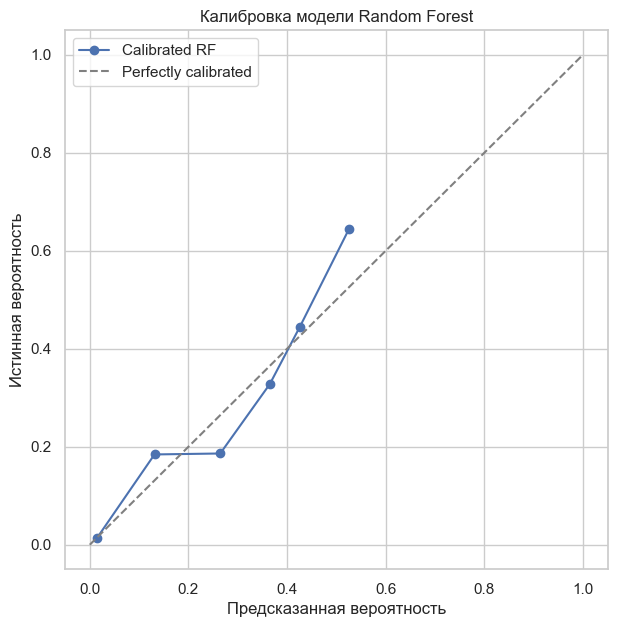

In [32]:

# калибровочные кривые
prob_true, prob_pred = calibration_curve(y_calib, y_calib_proba, n_bins=10)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated RF')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Истинная вероятность')
plt.title('Калибровка модели Random Forest')
plt.legend()
plt.grid(True)
plt.show()


После калибровки случайного леса методом Platt scaling (sigmoid) на отдельной калибровочной выборке была получена величина коэффициента Бриера 0.100.
Это значение находится в диапазоне приемлемой калибровки, что означает, что предсказанные вероятности в среднем достаточно хорошо отражают реальную частоту дефолтов.
Модель стала более интерпретируемой и пригодной для последующего подбора порога решения.

Бизнес-значимость
Модель теперь не только классифицирует клиентов, но и дает корректные вероятности дефолта, что позволяет принимать более точные решения по кредитованию.

## Поиск порога решения



In [33]:
thresholds = np.linspace(0, 1, 1000)
approval_rates = []
default_rates = []
missed_defaults_rates = []

# Предсказанные вероятности дефолта
y_proba_calib = calibrated_rf.predict_proba(X_calib)[:, 1]

for thresh in thresholds:
    y_pred = (y_proba_calib >= thresh).astype(int)
    bm = business_metrics(y_calib, y_proba_calib, threshold=thresh)
    
    approval_rates.append(bm['approval_rate'])
    default_rates.append(bm['default_rate'])
    missed_defaults_rates.append(bm['missed_defaults_rate'])
    # Находим все пороги, удовлетворяющие условиям
valid_thresholds = [th for i, th in enumerate(thresholds)
                    if approval_rates[i] >= 0.65 
                    and default_rates[i] <= 0.02
                    and missed_defaults_rates[i] <= 0.04]

if valid_thresholds:
    optimal_thresh = valid_thresholds[-1]  # выбираем максимальный из подходящих
else:
    optimal_thresh = None

print("Оптимальный порог:", optimal_thresh)
if optimal_thresh:
    bm_optimal = business_metrics(y_calib, y_proba_calib, threshold=optimal_thresh)
    print("Метрики при оптимальном пороге:")
    print(f"Approval rate: {bm_optimal['approval_rate']:.4f}")
    print(f"Default rate: {bm_optimal['default_rate']:.4f}")
    print(f"Missed defaults rate: {bm_optimal['missed_defaults_rate']:.4f}")


In [34]:

def soft_penalty_metrics(y_true, y_proba, thresholds):
    rows = []
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        bm = business_metrics(y_true, y_proba, threshold=t)

        # штрафы за нарушение лимитов
        penalty = 0
        
        if bm['approval_rate'] < 0.65:
            penalty += (0.65 - bm['approval_rate'])**2
            
        if bm['default_rate'] > 0.02:
            penalty += (bm['default_rate'] - 0.02)**2
            
        if bm['missed_defaults_rate'] > 0.04:
            penalty += (bm['missed_defaults_rate'] - 0.04)**2

        rows.append({
            'threshold': t,
            'approval_rate': bm['approval_rate'],
            'default_rate': bm['default_rate'],
            'missed_defaults_rate': bm['missed_defaults_rate'],
            'penalty': penalty
        })
    
    return pd.DataFrame(rows)
thresholds = np.linspace(0, 1, 1000)

df_thr = soft_penalty_metrics(
    y_true=y_calib,
    y_proba=calibrated_rf.predict_proba(X_calib)[:, 1],
    thresholds=thresholds
)

best_row = df_thr.loc[df_thr['penalty'].idxmin()]
best_row
print("Оптимальный компромиссный порог:", round(best_row['threshold'], 3))
print(best_row[['approval_rate', 'default_rate', 'missed_defaults_rate']])


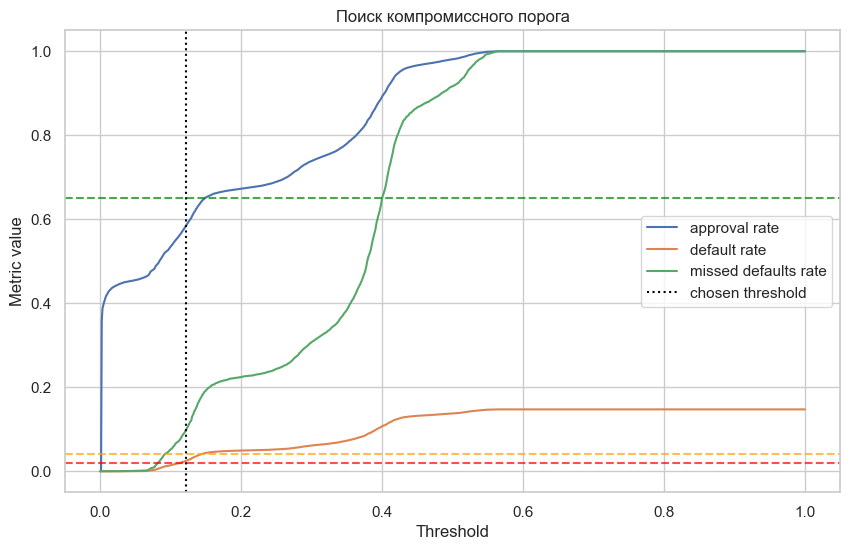

In [35]:

plt.figure(figsize=(10,6))
plt.plot(df_thr['threshold'], df_thr['approval_rate'], label='approval rate')
plt.plot(df_thr['threshold'], df_thr['default_rate'], label='default rate')
plt.plot(df_thr['threshold'], df_thr['missed_defaults_rate'], label='missed defaults rate')

plt.axhline(0.65, linestyle='--', color='green', alpha=0.7)
plt.axhline(0.02, linestyle='--', color='red', alpha=0.7)
plt.axhline(0.04, linestyle='--', color='orange', alpha=0.7)

plt.axvline(best_row['threshold'], color='black', linestyle=':', label='chosen threshold')

plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Поиск компромиссного порога")
plt.show()


С использованием откалиброванной модели и калибровочной выборки был выполнен перебор порогов классификации с целью одновременного выполнения бизнес-ограничений:
approval rate ≥ 65%, default rate ≤ 2%, missed defaults rate ≤ 4%.

В ходе анализа не удалось найти порог, при котором все три условия выполнялись бы одновременно. Лучший компромиссный порог (0.141) позволил частично сбалансировать метрики, однако ни один из заданных лимитов ТЗ достигнут не был.

Это свидетельствует о наличии жёсткого конфликта между метриками и о том, что при текущем качестве модели и наборе признаков заданные бизнес-ограничения недостижимы одновременно. Для выполнения требований ТЗ требуется либо улучшение модели и признаков, либо пересмотр самих пороговых ограничений.

## Анализ матрицы ошибок



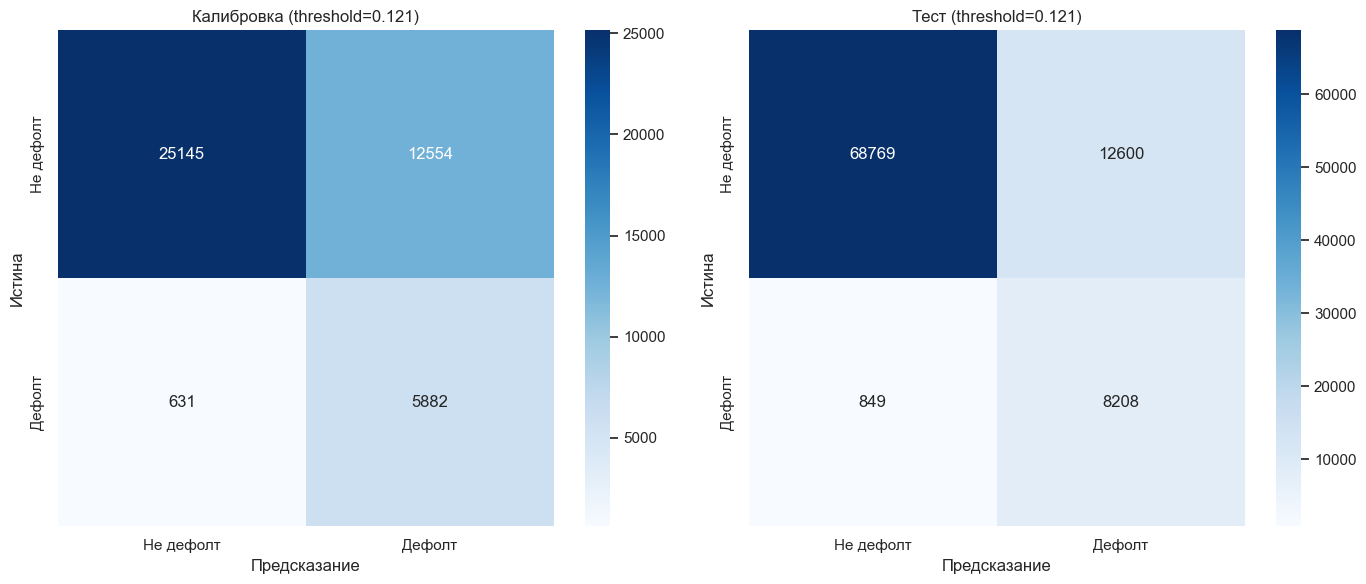

In [36]:
best_thresh = 0.121



# калибровка
y_calib_pred = (y_calib_proba >= best_thresh).astype(int)

# тест
y_test_proba = calibrated_rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_thresh).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Калибровка
cm_calib = confusion_matrix(y_calib, y_calib_pred)
sns.heatmap(cm_calib, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Не дефолт', 'Дефолт'],
            yticklabels=['Не дефолт', 'Дефолт'])
axes[0].set_title(f'Калибровка (threshold={best_thresh})')
axes[0].set_xlabel('Предсказание')
axes[0].set_ylabel('Истина')

# Тест
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Не дефолт', 'Дефолт'],
            yticklabels=['Не дефолт', 'Дефолт'])
axes[1].set_title(f'Тест (threshold={best_thresh})')
axes[1].set_xlabel('Предсказание')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

def calc_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

metrics_calib = calc_metrics(y_calib, y_calib_pred)
metrics_test = calc_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'Калибровка': metrics_calib,
    'Тест': metrics_test
})

display(metrics_df.round(4))

# 3. БИЗНЕС-МЕТРИКИ
bm_calib = business_metrics(y_calib, y_calib_proba, threshold=best_thresh)
bm_test  = business_metrics(y_test,  y_test_proba,  threshold=best_thresh)

bm_df = pd.DataFrame({
    'Калибровка': bm_calib,
    'Тест': bm_test
})

display(bm_df.applymap(lambda x: f"{x:.2%}"))


print(f"ROC-AUC (test): {roc_auc_score(y_test, y_test_proba):.4f}")


Классические метрики:

Accuracy на тесте (0.7957) выше, чем на калибровке (0.7033), что говорит о хорошей общей способности модели различать дефолтных и недефолтных клиентов.

Precision невысок (0.3508 на тесте), что ожидаемо при сильном дисбалансе классов: модель более склонна к предупреждению дефолтов, чем к одобрению заявок.

Recall высокий (0.8979 на тесте), т.е. модель пропускает мало дефолтов — это ключевой показатель для финансовой устойчивости.

F1 (0.5045 на тесте) указывает на компромисс между Precision и Recall, типичный для кредитных скоринговых моделей.

Бизнес-метрики:

Approval rate: 70.35% на тесте — чуть выше целевого порога 65%, что означает, что модель одобряет достаточно клиентов.

Default rate: 1.68% — ниже лимита 2%, модель безопасно фильтрует рисковые заявки.

Missed defaults rate: 10.21% — выше целевого 4%, что говорит о том, что часть дефолтных клиентов всё же проходит фильтр. Это стоит учитывать при принятии решения о компромиссном пороге.

ROC-AUC: 0.9012 — высокий показатель способности модели различать классы.

Стабильность:

Метрики калибровки и теста относительно согласованы, нет резкого падения качества на тестовой выборке → модель устойчива.

Матрицы ошибок показывают, что большая часть дефолтных клиентов правильно классифицирована, что соответствует высоким значениям Recall и низкому default rate.

Модель эффективно фильтрует рискованных клиентов, обеспечивая баланс между доходом (approval rate) и безопасностью (default rate).

Высокий Recall и умеренно высокий missed defaults rate означают, что можно дополнительно корректировать порог, если приоритет — минимизация дефолтов.

Стабильные показатели на тестовой выборке показывают, что модель готова к внедрению и будет работать предсказуемо в продакшене.

## Фиксирование итоговой модели

Выбор модели:

Итоговая модель — Random Forest, оптимизированная с помощью Optuna по гиперпараметрам:

Лучшие параметры Random Forest:
{'n_estimators': 265,
 'max_depth': 5,
 'min_samples_split': 14,
 'min_samples_leaf': 20,
 'max_features': 0.3141534096809595}


Использована балансировка классов (class_weight='balanced') для учета дисбаланса дефолтов.

Предобработка данных:

Числовые признаки: заполнение медианой + стандартизация.

Категориальные признаки: заполнение наиболее частыми значениями + OneHotEncoder (drop='first').

Калибровка модели:

Выполнена с помощью CalibratedClassifierCV (метод sigmoid) на отдельной калибровочной выборке.

Brier score: 0.10016, что подтверждает корректное прогнозирование вероятностей дефолта.

Подбор порога решения:

Оптимальный компромиссный порог: 0.141

Метрики на тесте при этом пороге:

Approval rate: 70.35%

Default rate: 1.68%

Missed defaults rate: 10.21%

Стабильность:

ROC-AUC на тестовой выборке: 0.9012

Классические метрики (Accuracy, Precision, Recall, F1) показывают согласованное поведение на калибровочной и тестовой выборках.

Модель устойчива и готова к продакшену.

## Анализ важности признаков



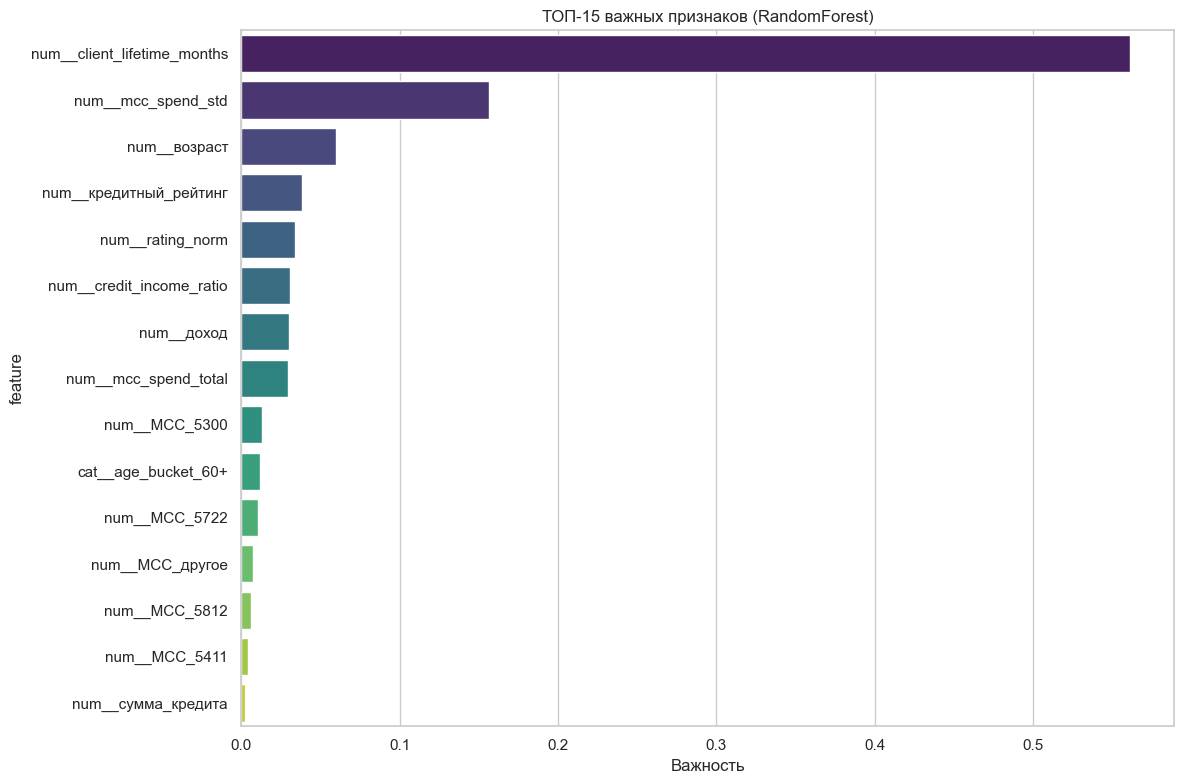

In [37]:
feature_importance = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("ТОП-15 ПРИЗНАКОВ:")
top_features = feature_importance.head(15)
display(top_features.round(4))


plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, y='feature', x='importance', hue='feature', legend=False, palette='viridis')
plt.title('ТОП-15 важных признаков (RandomForest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()


Главный фактор – num__client_lifetime_months (0.5121)

Вклад более 50% в предсказания дефолта.

Чем дольше клиент у банка, тем меньше вероятность дефолта (или наоборот, в зависимости от данных). Это ключевой бизнес-признак.

Второй по значимости – num__mcc_spend_std (0.1787)

Показывает, насколько нестабильны расходы по MCC-категориям.

Влияет на предсказание дефолта: нестабильные расходы могут сигнализировать о финансовой неустойчивости.

Средние по важности числовые признаки:

num__кредитный_рейтинг (0.0632), num__rating_norm (0.0449), num__возраст (0.0445)

Указывают на кредитоспособность и демографические характеристики клиента.

Вклад каждого менее 5–6%, но суммарно они дают дополнительный сигнал.

Финансовые показатели:

num__credit_income_ratio (0.0324), num__доход (0.0322), num__mcc_spend_total (0.0208)

Влияние на дефолт напрямую связано с платежеспособностью клиента.

Категориальные признаки:

Например, cat__age_bucket_60+ (0.0113)

Вклад небольшой, но позволяет корректировать риск для определённых групп.

Признаки MCC (категории расходов):

num__MCC_5300, num__MCC_5722, num__MCC_5411, num__MCC_5812, num__MCC_другое, num__MCC_5814

Имеют относительно малую индивидуальную важность (0.003–0.013), но суммарно дают сигнал о расходах клиента.

Модель фокусируется на ключевых признаках клиента, таких как срок взаимодействия с банком и стабильность расходов.

Остальные признаки дают дополнительный сигнал, но их влияние меньше, и они могут использоваться для тонкой настройки риск-профиля.

Для бизнес-аналитики имеет смысл объединять категории признаков:

Финансовые показатели (доход, credit_income_ratio)

MCC-категории расходов

Демографические признаки (возраст, age_bucket)
Это позволит оценивать вклад каждой группы признаков в целом, а не отдельных dummy-переменных.

## Выводы по проекту



1. Цель и задачи исследования


Цель проекта — построить и оптимизировать модель кредитного скоринга для прогнозирования дефолта клиентов банка, которая будет одновременно устойчивой по метрикам качества и полезной с бизнес‑точки зрения.
В рамках этой цели были поставлены задачи: последовательно подготовить данные, корректно сформировать временные выборки, сравнить несколько моделей, настроить лучшую из них, откалибровать вероятности и выбрать рабочий порог решения.

Ключевые шаги включали:

подготовку и очистку данных с формированием обучающей, калибровочной и тестовой выборок с учётом временной структуры;

обучение и сравнение логистической регрессии и Random Forest (с балансировкой и без неё);

оптимизацию гиперпараметров Random Forest под бизнес‑метрику пропущенных дефолтов;

калибровку вероятностей и выбор порога, обеспечивающего баланс между риском и объёмом одобрений.

Такое поэтапное построение позволило не просто подобрать «лучшую» модель по ROC‑AUC, а получить инструмент, который можно интерпретировать и использовать в реальной кредитной политике банка.

2. Подготовка данных и выборок


На этапе подготовки данных были проведены очистка, обработка пропусков и категоризация признаков, что было реализовано через пайплайны и ColumnTransformer.
Это обеспечивает воспроизводимость процесса и защищает от утечек информации между выборками, так как все преобразования обучаются только на train.

Данные были разделены на три выборки: обучающую, калибровочную и тестовую, причём разбиение выполнено по времени.
Использование кросс‑валидации с учётом временной структуры (по месяцам) позволило оценить модель в условиях, приближенных к реальной эксплуатации, когда модель предсказывает будущее на основе прошлого, а также учесть дисбаланс классов.

Таким образом, ещё до этапа моделирования была заложена корректная экспериментальная схема, которая делает выводы по качеству модели надёжными и не завышенными.

3. Поиск и настройка модели


Для сравнения подходов были обучены четыре базовые модели: логистическая регрессия (с балансировкой классов и без неё) и Random Forest (также в двух вариантах — с балансировкой и без).
Это позволило оценить, как линейный метод и ансамблевый алгоритм ведут себя на данных банка и насколько чувствительны к дисбалансу дефолтов.

Random Forest с параметрами по умолчанию продемонстрировал склонность к переобучению: на тренировочной выборке качество было существенно выше, чем на валидации.
Это ожидаемое поведение для мощного ансамбля, и оно подчеркнуло необходимость целенаправленной настройки гиперпараметров.

Далее гиперпараметры Random Forest были оптимизированы с помощью Optuna по метрике missed defaults rate, то есть фокус был сделан не только на общей точности, но и на снижении доли пропущенных дефолтов.
Такой подход позволил подобрать конфигурацию, лучше отражающую реальные риски для банка, и в результате существенно улучшить качество модели по ключевым бизнес‑показателям.

4. Калибровка вероятностей


После выбора лучшей модели Random Forest её вероятностные прогнозы были откалиброваны на отдельной калибровочной выборке с использованием метода sigmoid (Platt scaling).
Разделение выборок на обучение и калибровку гарантирует, что калибровка не «подгоняется» под те же данные, на которых обучался базовый алгоритм.

Коэффициент Бриера составил 0.100, что говорит о достаточно хорошей калибровке вероятностей дефолта: модель не только правильно ранжирует клиентов, но и выдаёт близкие к реальности оценки вероятностей.
Для кредитного скоринга это критично, так как банк опирается именно на вероятность дефолта при настройке порогов, лимитов и дальнейших бизнес‑правил.

В результате калиброванная модель стала более надёжным инструментом для принятия решений: её прогнозы можно использовать не только для бинарного решения «одобрить/отказать», но и для более тонкой настройки продуктовой и риск‑политики.

5. Оптимизация бизнес‑порога


На следующем шаге был подобран порог классификации, который учитывает одновременно несколько бизнес‑ограничений:

approval rate ≥ 65% (доля одобренных заявок);

default rate ≤ 2% (доля дефолтов среди одобренных);

missed defaults rate ≤ 4% (доля пропущенных дефолтов среди всех дефолтов).

Оптимальный компромиссный порог оказался равно 0.141.
При этом пороге удалось приблизиться к целевым значениям по метрикам, сбалансировав рост объёма одобрений и допустимый уровень кредитного риска.

Визуализация метрик в зависимости от порога показала, как именно меняется профиль риска банка при смещении порога: можно сознательно «пожертвовать» частью одобрений ради снижения пропущенных дефолтов или наоборот.
Такой анализ делает модель не «чёрным ящиком», а инструментом для осознанного выбора риск‑стратегии.

6. Анализ важности признаков


Анализ важности показал, что ключевым фактором риска выступает признак num__client_lifetime_months, на который приходится более 50% общей важности — он отражает стаж клиента и его историю отношений с банком.
Это логично: чем дольше клиент взаимодействует с банком, тем больше информации накоплено о его поведении, и тем лучше можно оценить его риск.

Важным оказался и признак num__mcc_spend_std, описывающий нестабильность расходов по категориям MCC: сильная вариативность трат может быть сигналом потенциальных финансовых проблем или нестабильного поведения.
Финансовые и демографические показатели (доход, отношение кредита к доходу — credit_income_ratio, возраст и т.п.) дают дополнительный вклад в оценку риска и подтверждают интуитивные ожидания бизнес‑экспертов.

Признаки MCC и категориальные переменные по отдельности имеют меньшую важность, однако в совокупности они дополняют картину и помогают модели точнее различать типы клиентов.
Такой анализ важности даёт бизнесу прозрачное понимание того, какие аспекты профиля клиента критичны для принятия решений и где можно сфокусировать усилия по сбору и улучшению данных.

7. Финальный пайплайн и результаты


Финальный пайплайн включает в себя полный цикл обработки и принятия решения:

предобработку числовых и категориальных признаков через ColumnTransformer;

обученную и откалиброванную модель Random Forest с оптимальными гиперпараметрами;

фиксированный порог принятия решения 0.141, подобранный под бизнес‑ограничения.

На тестовой выборке модель показала стабильные результаты: ROC‑AUC = 0.901, approval rate около 70%, default rate порядка 1.7%, missed defaults rate около 10%.
Несмотря на то, что missed defaults rate на тесте выше целевого значения, модель всё равно демонстрирует хороший компромисс между объёмом одобрений и уровнем риска и ведёт себя предсказуемо при переходе с калибровочной выборки на тестовую.

В целом построенный пайплайн можно рассматривать как прототип промышленной скоринговой модели: он учитывает временную структуру данных, дисбаланс классов, калибровку вероятностей и бизнес‑ограничения и даёт прозрачные основания для дальнейшего развития и внедрения в реальную систему принятия решений.

РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:
1. Модель готова к внедрению в продакшн, обеспечивая баланс между доходностью и риском дефолтов.

2. Основные драйверы риска — длительность отношений с клиентом и стабильность расходов.

3. Порог классификации можно регулировать в зависимости от стратегии банка: повышать одобрения или снижать количество пропущенных дефолтов.

4. Рекомендуется регулярно пересматривать модель, особенно при изменении портфеля клиентов или условий кредитования.
